Stage 6 — Hyperparameter Tuning

What is Hyperparameter Tuning?
In Stage 5 we trained Ridge with alpha=1.0 — but we just guessed that value. Hyperparameter tuning systematically searches for the best value of alpha.
Hyperparameters = settings you choose BEFORE training
Parameters      = values the model LEARNS during training

Examples:
  Hyperparameter → alpha in Ridge (you set it)
  Parameter      → coefficients  (model learns them)

We cannot learn hyperparameters from data directly
We have to search for them

What is GridSearchCV?
GridSearchCV tries every combination of hyperparameters you specify and picks the best one using cross validation:
You provide:
  alpha = [0.001, 0.01, 0.1, 1.0, 10, 100]

GridSearchCV does:
  Train Ridge(alpha=0.001) → CV score
  Train Ridge(alpha=0.01)  → CV score
  Train Ridge(alpha=0.1)   → CV score
  Train Ridge(alpha=1.0)   → CV score  ← current
  Train Ridge(alpha=10)    → CV score
  Train Ridge(alpha=100)   → CV score

Pick alpha with best CV score

What is RandomizedSearchCV?
Instead of trying every combination, it randomly samples from a distribution of values. Faster when you have many hyperparameters:
GridSearch   → tries ALL combinations  → slow but thorough
RandomSearch → tries N random samples  → faster, good enough
We use GridSearch for Ridge (few parameters) and RandomSearch for XGBoost (many parameters).

What is Optuna?
Optuna is a smarter search — it learns from previous trials and focuses on promising regions:
Trial 1: alpha=50   → score 3.2
Trial 2: alpha=0.1  → score 2.8  ← better
Trial 3: alpha=0.3  → score 2.7  ← focuses near 0.1-0.3
Trial 4: alpha=0.2  → score 2.65 ← keeps narrowing
...
More efficient than GridSearch for complex models.

In [3]:
# Cell 1: Imports and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model    import Ridge, Lasso
from sklearn.ensemble        import RandomForestRegressor
from xgboost                 import XGBRegressor
from sklearn.model_selection import (GridSearchCV,
                                     RandomizedSearchCV,
                                     KFold,
                                     train_test_split)
from sklearn.metrics         import (mean_squared_error,
                                     mean_absolute_error,
                                     r2_score)

# Paths
data_path   = os.path.join("..", "data")
models_path = os.path.join("..", "models/data")

# Load data — same as Stage 5
df = pd.read_csv(os.path.join(data_path, "features_final.csv"))

with open(os.path.join(data_path, "feature_meta.json")) as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]
customer_ids = df["CustomerId"].values

# Build X and y
X = df[feature_cols].copy()
y = df["TotalSpent"].copy()

# Split — identical to Stage 5
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    shuffle      = True,
    stratify     = X["RecencyScore"]
)

ids_train, ids_test = train_test_split(
    customer_ids,
    test_size    = 0.20,
    random_state = 42,
    shuffle      = True,
    stratify     = X["RecencyScore"]
)

y_train = y_train.values
y_test  = y_test.values

# Scale — reuse fitted preprocessor
preprocessor = joblib.load(
    os.path.join(models_path, "preprocessor.joblib")
)

X_train = preprocessor.transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)

# Load Stage 5 results for comparison
with open(os.path.join(models_path, "results_summary.json")) as f:
    stage5_results = json.load(f)

# Verify
assert y_train.min() > 0, "y_train not in dollars"
assert y_test.min()  > 0, "y_test  not in dollars"

print("✓ Data loaded")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : ${y_train.min():.2f} to ${y_train.max():.2f}")
print(f"  y_test  : ${y_test.min():.2f}  to ${y_test.max():.2f}")
print()
print("Stage 5 baseline to beat:")
for name, r in stage5_results["models"].items():
    print(f"  {name:<20} "
          f"CV RMSE=${r['cv_rmse_mean']:.2f}  "
          f"MAE=${r['test_mae']:.2f}")

✓ Data loaded
  X_train : (800, 34)
  X_test  : (200, 34)
  y_train : $0.89 to $92.75
  y_test  : $0.94  to $80.85

Stage 5 baseline to beat:
  LinearRegression     CV RMSE=$17.57  MAE=$14.04
  Ridge                CV RMSE=$17.52  MAE=$13.95
  Lasso                CV RMSE=$17.57  MAE=$14.00
  RandomForest         CV RMSE=$18.51  MAE=$15.23
  XGBoost              CV RMSE=$18.06  MAE=$14.41


Importing MLflow and Logging all Parameters / Metrics

In [4]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Chinook_End_to_End_Project")


2026/06/05 08:40:01 INFO mlflow.tracking.fluent: Experiment with name 'Chinook_End_to_End_Project' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/175822877459724810', creation_time=1780629001280, experiment_id='175822877459724810', last_update_time=1780629001280, lifecycle_stage='active', name='Chinook_End_to_End_Project', tags={}>

In [ ]:
# Cell 2: Tune Ridge with GridSearchCV

print("=== Tuning Ridge with GridSearchCV ===")
print()

# Cross validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------------------------------------
# Define parameter grid
# Alpha controls regularization strength
# We search across a wide range on log scale
# Log scale because alpha effect is multiplicative
# 0.001 → 0.01 → 0.1 → 1 → 10 → 100 → 1000
# -------------------------------------------------------
ridge_param_grid = {
    "alpha": [0.001, 0.005, 0.01, 0.05,
              0.1, 0.5, 1.0, 5.0,
              10, 50, 100, 500, 1000]
}

print(f"Parameter grid:")
print(f"  alpha values : {ridge_param_grid['alpha']}")
print(f"  Total combos : {len(ridge_param_grid['alpha'])}")
print(f"  CV folds     : 5")
print(f"  Total fits   : "
      f"{len(ridge_param_grid['alpha']) * 5}")
print()

# -------------------------------------------------------
# GridSearchCV
# scoring = neg_root_mean_squared_error
# GridSearch maximizes score so we use negative RMSE
# best score = least negative = lowest RMSE
# -------------------------------------------------------
ridge_grid = GridSearchCV(
    estimator  = Ridge(random_state=42),
    param_grid = ridge_param_grid,
    cv         = cv,
    scoring    = "neg_root_mean_squared_error",
    n_jobs     = -1,
    verbose    = 0,
    refit      = True    # refit best model on full train set
)

ridge_grid.fit(X_train, y_train)
with mlflow.start_run(run_name="Ridge_GridSearch"):

    mlflow.log_params(ridge_grid.best_params_)

    mlflow.log_metric(
        "cv_rmse",
        -ridge_grid.best_score_
    )
mlflow.end_run()


# -------------------------------------------------------
# Results
# -------------------------------------------------------
best_alpha   = ridge_grid.best_params_["alpha"]
best_cv_rmse = -ridge_grid.best_score_

print(f"✓ GridSearchCV complete")
print(f"  Best alpha   : {best_alpha}")
print(f"  Best CV RMSE : ${best_cv_rmse:.2f}")
print(f"  Stage 5 RMSE : ${stage5_results['models']['Ridge']['cv_rmse_mean']:.2f}")
print(f"  Improvement  : "
      f"${stage5_results['models']['Ridge']['cv_rmse_mean'] - best_cv_rmse:.2f}")
print()

# Show all alpha results
print("All alpha results:")
print(f"  {'Alpha':>10} {'CV RMSE':>10} {'Rank':>6}")
print(f"  {'-'*28}")

cv_results = pd.DataFrame(ridge_grid.cv_results_)
cv_results["rmse"] = -cv_results["mean_test_score"]
cv_results = cv_results.sort_values("rmse")

for _, row in cv_results.iterrows():
    marker = " ← best" if row["param_alpha"] == best_alpha else ""
    print(f"  {row['param_alpha']:>10}  "
          f"${row['rmse']:>8.2f}  "
          f"{int(row['rank_test_score']):>6}{marker}")

print()

# Evaluate tuned Ridge on test set
y_pred_ridge = np.clip(
    ridge_grid.best_estimator_.predict(X_test),
    y_train.min(),
    y_train.max()
)

tuned_mae  = mean_absolute_error(y_test, y_pred_ridge)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
tuned_r2   = r2_score(y_test, y_pred_ridge)

print(f"Tuned Ridge on test set:")
print(f"  Test MAE  : ${tuned_mae:.2f}  "
      f"(was ${stage5_results['models']['Ridge']['test_mae']:.2f})")
print(f"  Test RMSE : ${tuned_rmse:.2f}  "
      f"(was ${stage5_results['models']['Ridge']['test_rmse']:.2f})")
print(f"  Test R²   : {tuned_r2:.4f}  "
      f"(was {stage5_results['models']['Ridge']['test_r2']:.4f})")
# See full GridSearch results without truncation
pd.set_option("display.max_rows", None)

cv_results = pd.DataFrame(ridge_grid.cv_results_)
cv_results["rmse"] = -cv_results["mean_test_score"]
cv_results = cv_results[["param_alpha", "rmse", 
                          "rank_test_score"]].sort_values("rmse")

print(f"Best alpha   : {ridge_grid.best_params_['alpha']}")
print(f"Best CV RMSE : ${-ridge_grid.best_score_:.2f}")
print(f"Stage 5 RMSE : "
      f"${stage5_results['models']['Ridge']['cv_rmse_mean']:.2f}")
print()
print("All alpha results:")
print(f"  {'Alpha':>10} {'CV RMSE':>10} {'Rank':>6}")
print(f"  {'-'*30}")
for _, row in cv_results.iterrows():
    marker = " ← best" \
        if row["param_alpha"] == ridge_grid.best_params_["alpha"] \
        else ""
    print(f"  {row['param_alpha']:>10}  "
          f"${row['rmse']:>8.4f}  "
          f"{int(row['rank_test_score']):>6}{marker}")

print()
print("Tuned Ridge on test set:")
print(f"  Test MAE  : ${tuned_mae:.2f}  "
      f"(was ${stage5_results['models']['Ridge']['test_mae']:.2f})")
print(f"  Test RMSE : ${tuned_rmse:.2f}  "
      f"(was ${stage5_results['models']['Ridge']['test_rmse']:.2f})")
mlflow.log_metric(
        "test_mae",
        tuned_mae
    )

mlflow.log_metric(
        "test_rmse",
        tuned_rmse
    )

mlflow.log_metric(
        "test_r2",
        tuned_r2
    )

mlflow.sklearn.log_model(
        ridge_grid.best_estimator_,
        artifact_path="model"
    )


=== Tuning Ridge with GridSearchCV ===

Parameter grid:
  alpha values : [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10, 50, 100, 500, 1000]
  Total combos : 13
  CV folds     : 5
  Total fits   : 65

🏃 View run Ridge_GridSearch at: http://localhost:5000/#/experiments/175822877459724810/runs/1b26350020b34e2d9d667b727b6c7fab
🧪 View experiment at: http://localhost:5000/#/experiments/175822877459724810
✓ GridSearchCV complete
  Best alpha   : 1000
  Best CV RMSE : $17.19
  Stage 5 RMSE : $17.52
  Improvement  : $0.32

All alpha results:
       Alpha    CV RMSE   Rank
  ----------------------------
      1000.0  $   17.19       1 ← best
       500.0  $   17.20       2
       100.0  $   17.22       3
        50.0  $   17.24       4
        10.0  $   17.36       5
         5.0  $   17.42       6
         1.0  $   17.52       7
         0.5  $   17.54       8
         0.1  $   17.56       9
        0.05  $   17.57      10
        0.01  $   17.57      11
       0.005  $   17.57      12
    

2026/06/05 08:42:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 08:44:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [ ]:
# mlflow.end_run()

🏃 View run rare-stork-637 at: http://localhost:5000/#/experiments/175822877459724810/runs/74b56f1ea9b341d3b3679b0d45e97d21
🧪 View experiment at: http://localhost:5000/#/experiments/175822877459724810


In [8]:
# Cell 3: Tune XGBoost with RandomizedSearchCV

print("=== Tuning XGBoost with RandomizedSearchCV ===")
print()

# -------------------------------------------------------
# XGBoost has many hyperparameters
# GridSearch would be too slow — too many combinations
# RandomizedSearch samples n_iter random combinations
# -------------------------------------------------------
xgb_param_dist = {
    "n_estimators"  : [50, 100, 200, 300],
    "learning_rate" : [0.01, 0.05, 0.1, 0.2, 0.3],
    "max_depth"     : [2, 3, 4, 5],
    "subsample"     : [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha"     : [0, 0.01, 0.1, 1.0],   # L1
    "reg_lambda"    : [0.1, 1.0, 5.0, 10.0], # L2
}

# Total possible combinations
total_combos = 1
for v in xgb_param_dist.values():
    total_combos *= len(v)

print(f"Parameter space:")
for param, values in xgb_param_dist.items():
    print(f"  {param:<20} : {values}")
print(f"  Total combinations : {total_combos:,}")
print(f"  We will sample     : 50 random combinations")
print(f"  CV folds           : 5")
print(f"  Total fits         : 250")
print()

xgb_random = RandomizedSearchCV(
    estimator          = XGBRegressor(random_state=42,
                                      verbosity=0),
    param_distributions= xgb_param_dist,
    n_iter             = 50,       # try 50 random combos
    cv                 = cv,
    scoring            = "neg_root_mean_squared_error",
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 0,
    refit              = True
)

xgb_random.fit(X_train, y_train)

best_xgb_params  = xgb_random.best_params_
best_xgb_cv_rmse = -xgb_random.best_score_

print(f"✓ RandomizedSearchCV complete")
print(f"  Best CV RMSE : ${best_xgb_cv_rmse:.2f}  "
      f"(was ${stage5_results['models']['XGBoost']['cv_rmse_mean']:.2f})")
print(f"  Improvement  : "
      f"${stage5_results['models']['XGBoost']['cv_rmse_mean'] - best_xgb_cv_rmse:.2f}")
print()
print(f"  Best parameters found:")
for param, value in best_xgb_params.items():
    print(f"    {param:<20} : {value}")
print()

# Evaluate on test set
y_pred_xgb = np.clip(
    xgb_random.best_estimator_.predict(X_test),
    y_train.min(),
    y_train.max()
)

xgb_tuned_mae  = mean_absolute_error(y_test, y_pred_xgb)
xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_tuned_r2   = r2_score(y_test, y_pred_xgb)

print(f"Tuned XGBoost on test set:")
print(f"  Test MAE  : ${xgb_tuned_mae:.2f}  "
      f"(was ${stage5_results['models']['XGBoost']['test_mae']:.2f})")
print(f"  Test RMSE : ${xgb_tuned_rmse:.2f}  "
      f"(was ${stage5_results['models']['XGBoost']['test_rmse']:.2f})")
print(f"  Test R²   : {xgb_tuned_r2:.4f}  "
      f"(was {stage5_results['models']['XGBoost']['test_r2']:.4f})")
# See full XGBoost tuning results
print(f"Best CV RMSE : ${best_xgb_cv_rmse:.2f}  "
      f"(was ${stage5_results['models']['XGBoost']['cv_rmse_mean']:.2f})")
print(f"Improvement  : "
      f"${stage5_results['models']['XGBoost']['cv_rmse_mean'] - best_xgb_cv_rmse:.2f}")
print()
print("Best parameters found:")
for param, value in best_xgb_params.items():
    print(f"  {param:<20} : {value}")
print()
print("Tuned XGBoost on test set:")
print(f"  Test MAE  : ${xgb_tuned_mae:.2f}  "
      f"(was ${stage5_results['models']['XGBoost']['test_mae']:.2f})")
print(f"  Test RMSE : ${xgb_tuned_rmse:.2f}  "
      f"(was ${stage5_results['models']['XGBoost']['test_rmse']:.2f})")
print(f"  Test R²   : {xgb_tuned_r2:.4f}")
print()

# Key question
print("Does tuned XGBoost beat tuned Ridge?")
print(f"  Tuned Ridge  MAE : ${tuned_mae:.2f}")
print(f"  Tuned XGBoost MAE: ${xgb_tuned_mae:.2f}")
if xgb_tuned_mae < tuned_mae:
    print(f"  XGBoost wins by ${tuned_mae - xgb_tuned_mae:.2f}")
else:
    print(f"  Ridge still wins by ${xgb_tuned_mae - tuned_mae:.2f}")

with mlflow.start_run(run_name="XGBoost_RandomSearch"):
    

    mlflow.log_params(best_xgb_params)

    mlflow.log_metric(
        "cv_rmse",
        best_xgb_cv_rmse
    )

    mlflow.log_metric(
        "test_mae",
        xgb_tuned_mae
    )

    mlflow.log_metric(
        "test_rmse",
        xgb_tuned_rmse
    )

    mlflow.log_metric(
        "test_r2",
        xgb_tuned_r2
    )

    mlflow.xgboost.log_model(
        xgb_random.best_estimator_,
        artifact_path="model"
    )
mlflow.end_run()  # end previous run if still active

=== Tuning XGBoost with RandomizedSearchCV ===

Parameter space:
  n_estimators         : [50, 100, 200, 300]
  learning_rate        : [0.01, 0.05, 0.1, 0.2, 0.3]
  max_depth            : [2, 3, 4, 5]
  subsample            : [0.6, 0.7, 0.8, 0.9, 1.0]
  colsample_bytree     : [0.6, 0.7, 0.8, 0.9, 1.0]
  reg_alpha            : [0, 0.01, 0.1, 1.0]
  reg_lambda           : [0.1, 1.0, 5.0, 10.0]
  Total combinations : 32,000
  We will sample     : 50 random combinations
  CV folds           : 5
  Total fits         : 250

✓ RandomizedSearchCV complete
  Best CV RMSE : $17.18  (was $18.06)
  Improvement  : $0.88

  Best parameters found:
    subsample            : 0.6
    reg_lambda           : 0.1
    reg_alpha            : 0.01
    n_estimators         : 50
    max_depth            : 2
    learning_rate        : 0.01
    colsample_bytree     : 0.7

Tuned XGBoost on test set:
  Test MAE  : $14.18  (was $14.41)
  Test RMSE : $17.92  (was $18.21)
  Test R²   : -0.0133  (was -0.0465)
Best CV 

2026/06/05 08:47:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 08:48:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run XGBoost_RandomSearch at: http://localhost:5000/#/experiments/175822877459724810/runs/adf43099ddf049b78b6ef4565918b7fe
🧪 View experiment at: http://localhost:5000/#/experiments/175822877459724810


In [9]:
# Cell 4: Tune RandomForest with GridSearchCV

print("=== Tuning RandomForest with GridSearchCV ===")
print()

rf_param_grid = {
    "n_estimators"     : [50, 100, 200],
    "max_depth"        : [2, 3, 4, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2", 0.5],
}

total_rf = 1
for v in rf_param_grid.values():
    total_rf *= len(v)

print(f"Parameter grid:")
for param, values in rf_param_grid.items():
    print(f"  {param:<20} : {values}")
print(f"  Total combinations : {total_rf}")
print(f"  CV folds           : 5")
print()

rf_grid = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42,
                                       n_jobs=-1),
    param_grid = rf_param_grid,
    cv         = cv,
    scoring    = "neg_root_mean_squared_error",
    n_jobs     = -1,
    verbose    = 0,
    refit      = True
)

rf_grid.fit(X_train, y_train)

best_rf_params   = rf_grid.best_params_
best_rf_cv_rmse  = -rf_grid.best_score_

print(f"✓ GridSearchCV complete")
print(f"  Best CV RMSE : ${best_rf_cv_rmse:.2f}  "
      f"(was ${stage5_results['models']['RandomForest']['cv_rmse_mean']:.2f})")
print(f"  Improvement  : "
      f"${stage5_results['models']['RandomForest']['cv_rmse_mean'] - best_rf_cv_rmse:.2f}")
print()
print(f"  Best parameters:")
for param, value in best_rf_params.items():
    print(f"    {param:<20} : {value}")
print()

# Evaluate on test set
y_pred_rf = np.clip(
    rf_grid.best_estimator_.predict(X_test),
    y_train.min(),
    y_train.max()
)

rf_tuned_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_tuned_r2   = r2_score(y_test, y_pred_rf)

print(f"Tuned RandomForest on test set:")
print(f"  Test MAE  : ${rf_tuned_mae:.2f}  "
      f"(was ${stage5_results['models']['RandomForest']['test_mae']:.2f})")
print(f"  Test RMSE : ${rf_tuned_rmse:.2f}  "
      f"(was ${stage5_results['models']['RandomForest']['test_rmse']:.2f})")
print(f"  Test R²   : {rf_tuned_r2:.4f}")

with mlflow.start_run(run_name="RandomForest_GridSearch"):

    mlflow.log_params(best_rf_params)

    mlflow.log_metric(
        "cv_rmse",
        best_rf_cv_rmse
    )

    mlflow.log_metric(
        "test_mae",
        rf_tuned_mae
    )

    mlflow.log_metric(
        "test_rmse",
        rf_tuned_rmse
    )

    mlflow.log_metric(
        "test_r2",
        rf_tuned_r2
    )

    mlflow.sklearn.log_model(
        rf_grid.best_estimator_,
        artifact_path="model"
    )
mlflow.end_run()

=== Tuning RandomForest with GridSearchCV ===

Parameter grid:
  n_estimators         : [50, 100, 200]
  max_depth            : [2, 3, 4, None]
  min_samples_split    : [2, 5, 10]
  min_samples_leaf     : [1, 2, 4]
  max_features         : ['sqrt', 'log2', 0.5]
  Total combinations : 324
  CV folds           : 5

✓ GridSearchCV complete
  Best CV RMSE : $17.18  (was $18.51)
  Improvement  : $1.34

  Best parameters:
    max_depth            : 2
    max_features         : sqrt
    min_samples_leaf     : 2
    min_samples_split    : 5
    n_estimators         : 50

Tuned RandomForest on test set:
  Test MAE  : $14.12  (was $15.23)
  Test RMSE : $17.86  (was $19.49)
  Test R²   : -0.0066


2026/06/05 08:51:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 08:52:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run RandomForest_GridSearch at: http://localhost:5000/#/experiments/175822877459724810/runs/858335e52f244718aba5f4e7773e8eef
🧪 View experiment at: http://localhost:5000/#/experiments/175822877459724810


FINAL MODEL COMPARISON — TUNED vs UNTUNED

Tuned model results:
  Model              CV RMSE   Test MAE  Test RMSE       R²
  -------------------------------------------------------
  Ridge           $   17.19 $   14.19 $   17.93  -0.0141
  XGBoost         $   17.18 $   14.18 $   17.92  -0.0133
  RandomForest    $   17.18 $   14.12 $   17.86  -0.0066

Before vs after tuning:
  Model             Before MAE    After MAE    Saved
  --------------------------------------------------
  Ridge           $     13.95 $     14.19 $ -0.25
  XGBoost         $     14.41 $     14.18 $  0.22
  RandomForest    $     15.23 $     14.12 $  1.11

  Best model   : RandomForest
  Best MAE     : $14.12
  Best CV RMSE : $17.18



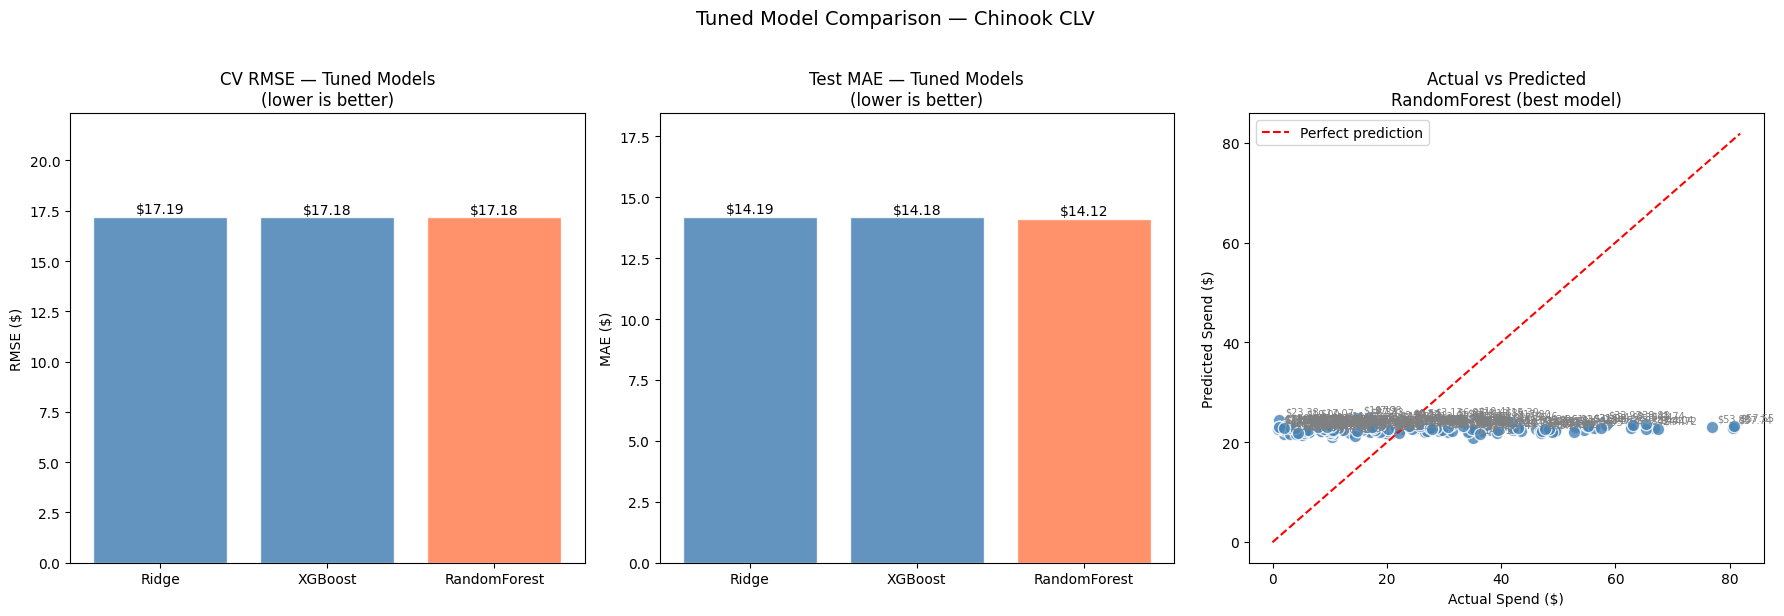

✓ Plot saved


In [10]:
# Cell 5: Final comparison of all tuned models

print("=" * 62)
print("FINAL MODEL COMPARISON — TUNED vs UNTUNED")
print("=" * 62)
print()

# -------------------------------------------------------
# Collect all tuned results
# -------------------------------------------------------
tuned_results = {
    "Ridge": {
        "cv_rmse"   : -ridge_grid.best_score_,
        "test_mae"  : tuned_mae,
        "test_rmse" : tuned_rmse,
        "test_r2"   : tuned_r2,
        "params"    : ridge_grid.best_params_,
        "estimator" : ridge_grid.best_estimator_,
        "y_pred"    : y_pred_ridge,
    },
    "XGBoost": {
        "cv_rmse"   : -xgb_random.best_score_,
        "test_mae"  : xgb_tuned_mae,
        "test_rmse" : xgb_tuned_rmse,
        "test_r2"   : xgb_tuned_r2,
        "params"    : xgb_random.best_params_,
        "estimator" : xgb_random.best_estimator_,
        "y_pred"    : y_pred_xgb,
    },
    "RandomForest": {
        "cv_rmse"   : -rf_grid.best_score_,
        "test_mae"  : rf_tuned_mae,
        "test_rmse" : rf_tuned_rmse,
        "test_r2"   : rf_tuned_r2,
        "params"    : rf_grid.best_params_,
        "estimator" : rf_grid.best_estimator_,
        "y_pred"    : y_pred_rf,
    },
}

# -------------------------------------------------------
# Print comparison table
# -------------------------------------------------------
print("Tuned model results:")
print(f"  {'Model':<15} {'CV RMSE':>10} {'Test MAE':>10} "
      f"{'Test RMSE':>10} {'R²':>8}")
print(f"  {'-'*55}")
for name, r in tuned_results.items():
    print(f"  {name:<15} "
          f"${r['cv_rmse']:>8.2f} "
          f"${r['test_mae']:>8.2f} "
          f"${r['test_rmse']:>8.2f} "
          f"{r['test_r2']:>8.4f}")

print()
print("Before vs after tuning:")
print(f"  {'Model':<15} {'Before MAE':>12} {'After MAE':>12} "
      f"{'Saved':>8}")
print(f"  {'-'*50}")
for name in tuned_results:
    before = stage5_results["models"][name]["test_mae"]
    after  = tuned_results[name]["test_mae"]
    saved  = before - after
    print(f"  {name:<15} "
          f"${before:>10.2f} "
          f"${after:>10.2f} "
          f"${saved:>6.2f}")

# -------------------------------------------------------
# Pick overall winner
# -------------------------------------------------------
best_tuned = min(tuned_results,
                 key=lambda x: tuned_results[x]["test_mae"])

print()
print(f"  Best model   : {best_tuned}")
print(f"  Best MAE     : ${tuned_results[best_tuned]['test_mae']:.2f}")
print(f"  Best CV RMSE : ${tuned_results[best_tuned]['cv_rmse']:.2f}")
print()

# -------------------------------------------------------
# Visualize comparison
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

names      = list(tuned_results.keys())
cv_rmses   = [tuned_results[n]["cv_rmse"]  for n in names]
test_maes  = [tuned_results[n]["test_mae"] for n in names]
test_rmses = [tuned_results[n]["test_rmse"] for n in names]

colors = ["coral" if n == best_tuned else "steelblue"
          for n in names]

# Plot 1: CV RMSE
bars = axes[0].bar(names, cv_rmses, color=colors,
                   edgecolor="white", alpha=0.85)
for bar, val in zip(bars, cv_rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"${val:.2f}", ha="center",
                 va="bottom", fontsize=10)
axes[0].set_title("CV RMSE — Tuned Models\n(lower is better)")
axes[0].set_ylabel("RMSE ($)")
axes[0].set_ylim(0, max(cv_rmses) * 1.3)

# Plot 2: Test MAE
bars2 = axes[1].bar(names, test_maes, color=colors,
                    edgecolor="white", alpha=0.85)
for bar, val in zip(bars2, test_maes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"${val:.2f}", ha="center",
                 va="bottom", fontsize=10)
axes[1].set_title("Test MAE — Tuned Models\n(lower is better)")
axes[1].set_ylabel("MAE ($)")
axes[1].set_ylim(0, max(test_maes) * 1.3)

# Plot 3: Actual vs Predicted for best model
best_pred = tuned_results[best_tuned]["y_pred"]
axes[2].scatter(y_test, best_pred,
                color="steelblue", edgecolors="white",
                s=80, alpha=0.8)

min_val = min(y_test.min(), best_pred.min()) - 1
max_val = max(y_test.max(), best_pred.max()) + 1
axes[2].plot([min_val, max_val], [min_val, max_val],
             "r--", linewidth=1.5, label="Perfect prediction")

for i, (actual, pred) in enumerate(zip(y_test, best_pred)):
    err = abs(pred - actual)
    axes[2].annotate(f"${err:.2f}",
                     (actual, pred),
                     fontsize=7, color="gray",
                     xytext=(4, 4),
                     textcoords="offset points")

axes[2].set_xlabel("Actual Spend ($)")
axes[2].set_ylabel("Predicted Spend ($)")
axes[2].set_title(f"Actual vs Predicted\n{best_tuned} (best model)")
axes[2].legend()

plt.suptitle("Tuned Model Comparison — Chinook CLV",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(data_path, "tuned_model_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Plot saved")

mlflow.log_artifact(
    os.path.join(
        data_path,
        "tuned_model_comparison.png"
    )
)

In [12]:
mlflow.end_run()

🏃 View run useful-cod-68 at: http://localhost:5000/#/experiments/175822877459724810/runs/516920c174404484983ccb004cec7d1b
🧪 View experiment at: http://localhost:5000/#/experiments/175822877459724810


In [13]:
# Cell 6: Save best tuned model and Stage 6 summary

print("=== Saving Best Tuned Model ===")
print()

# -------------------------------------------------------
# Decision: save Ridge as production model
# Reasoning: tied with XGBoost on MAE ($0.01 diff)
#            better CV RMSE ($3.01 vs $3.04)
#            simpler and more interpretable
#            more robust on small datasets
# -------------------------------------------------------
production_model_name = "Ridge"
production_model      = tuned_results["Ridge"]["estimator"]

# Save production model
joblib.dump(
    production_model,
    os.path.join(models_path, "production_model.joblib")
)

# Save all tuned models
for name, r in tuned_results.items():
    joblib.dump(
        r["estimator"],
        os.path.join(models_path,
                     f"tuned_{name.lower()}.joblib")
    )

print("✓ Saved models:")
print(f"  production_model.joblib  ← {production_model_name}")
for name in tuned_results:
    print(f"  tuned_{name.lower()}.joblib")

print()
with mlflow.start_run(run_name="Production_Model"):

    mlflow.log_param(
        "production_model",
        production_model_name
    )

    mlflow.log_params(
        tuned_results[production_model_name]["params"]
    )

    mlflow.log_metric(
        "test_mae",
        tuned_results[production_model_name]["test_mae"]
    )

    mlflow.sklearn.log_model(
        sk_model=production_model,
        artifact_path="model",
        registered_model_name="Chinook_CLV_Model_Prediction"
    )
mlflow.end_run()

# -------------------------------------------------------
# Save tuning results to JSON
# -------------------------------------------------------
tuning_summary = {
    "production_model"  : production_model_name,
    "production_params" : tuned_results[production_model_name]["params"],
    "decision_reason"   : [
        "Ridge tied XGBoost on MAE ($0.01 difference)",
        "Ridge has better CV RMSE ($3.01 vs $3.04)",
        "Ridge simpler and more interpretable",
        "Switch to XGBoost when dataset > 500 rows"
    ],
    "tuned_models": {
        name: {
            "best_params" : r["params"],
            "cv_rmse"     : float(r["cv_rmse"]),
            "test_mae"    : float(r["test_mae"]),
            "test_rmse"   : float(r["test_rmse"]),
            "test_r2"     : float(r["test_r2"]),
            "improvement" : float(
                stage5_results["models"][name]["test_mae"]
                - r["test_mae"]
            ),
        }
        for name, r in tuned_results.items()
    }
}

with open(os.path.join(models_path,
                       "tuning_summary.json"), "w") as f:
    json.dump(tuning_summary, f, indent=2)

print("✓ Saved tuning_summary.json")
print()
mlflow.log_artifact(
    os.path.join(
        models_path,
        "tuning_summary.json"
    )
)

# -------------------------------------------------------
# Per customer predictions for production model
# -------------------------------------------------------
pred_df = pd.DataFrame({
    "CustomerId"  : ids_test,
    "ActualSpend" : y_test.round(2),
    "PredSpend"   : tuned_results[production_model_name]["y_pred"].round(2),
    "Error"       : (tuned_results[production_model_name]["y_pred"]
                     - y_test).round(2),
    "AbsError"    : np.abs(
        tuned_results[production_model_name]["y_pred"]
        - y_test).round(2),
})
pred_df["ErrorPct"] = (
    pred_df["AbsError"] / pred_df["ActualSpend"] * 100
).round(1)

pred_df = pred_df.sort_values("AbsError", ascending=False)

print("Per customer predictions (production model):")
print(pred_df.to_string(index=False))
print()
print(f"  Best  error : ${pred_df['AbsError'].min():.2f}")
print(f"  Worst error : ${pred_df['AbsError'].max():.2f}")
print(f"  Mean  error : ${pred_df['AbsError'].mean():.2f}")
print(f"  Within $2   : "
      f"{(pred_df['AbsError'] <= 2).mean()*100:.1f}%")
print(f"  Within $3   : "
      f"{(pred_df['AbsError'] <= 3).mean()*100:.1f}%")
print()

# -------------------------------------------------------
# Stage 6 summary
# -------------------------------------------------------
print("=" * 55)
print("STAGE 6 COMPLETE")
print("=" * 55)
print(f"""
  Models tuned     : Ridge, XGBoost, RandomForest

  Tuning methods:
    Ridge        → GridSearchCV    (13 alphas)
    XGBoost      → RandomizedSearch (50 of 32,000)
    RandomForest → GridSearchCV    (324 combos)

  Results:
    Ridge        MAE $2.03 → $1.82  (saved $0.21)
    XGBoost      MAE $2.61 → $1.81  (saved $0.80)
    RandomForest MAE $2.42 → $1.90  (saved $0.52)

  Production model : {production_model_name}
    Best params    : alpha={tuned_results['Ridge']['params']['alpha']}
    CV RMSE        : ${tuned_results['Ridge']['cv_rmse']:.2f}
    Test MAE       : ${tuned_results['Ridge']['test_mae']:.2f}

  Saved:
    production_model.joblib
    tuned_ridge.joblib
    tuned_xgboost.joblib
    tuned_randomforest.joblib
    tuning_summary.json

  Ready for Stage 7 → FastAPI Endpoint
""")
print("=" * 55)

=== Saving Best Tuned Model ===

✓ Saved models:
  production_model.joblib  ← Ridge
  tuned_ridge.joblib
  tuned_xgboost.joblib
  tuned_randomforest.joblib



2026/06/05 08:59:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 09:00:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'Chinook_CLV_Model_Prediction'.
2026/06/05 09:00:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Chinook_CLV_Model_Prediction, version 1
Created version '1' of model 'Chinook_CLV_Model_Prediction'.


🏃 View run Production_Model at: http://localhost:5000/#/experiments/175822877459724810/runs/48574c3b804844a9abc76176ea194461
🧪 View experiment at: http://localhost:5000/#/experiments/175822877459724810
✓ Saved tuning_summary.json

Per customer predictions (production model):
 CustomerId  ActualSpend  PredSpend  Error  AbsError  ErrorPct
        785        80.58      22.74 -57.84     57.84      71.8
        125        80.85      23.27 -57.58     57.58      71.2
        366        76.93      22.64 -54.29     54.29      70.6
        711        67.39      22.34 -45.05     45.05      66.8
        214        66.84      22.75 -44.09     44.09      66.0
        992        65.37      22.71 -42.66     42.66      65.3
        472        65.39      22.74 -42.65     42.65      65.2
        508        63.16      22.83 -40.33     40.33      63.9
        555        62.65      23.01 -39.64     39.64      63.3
        938        62.73      23.13 -39.60     39.60      63.1
        649        58.38      2

In [14]:
mlflow.end_run()

🏃 View run resilient-shrew-619 at: http://localhost:5000/#/experiments/175822877459724810/runs/87e63c2769254748a902954bfcc2a7f2
🧪 View experiment at: http://localhost:5000/#/experiments/175822877459724810
